# Homework Starter: Final Reporting

This notebook helps you generate plots, annotate assumptions, and prepare a stakeholder-ready deliverable.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib

## Executive Summary
- Baseline scenario shows steady returns with moderate volatility.
- Imputation and outlier adjustments create small variations in return and risk.
- Key assumptions and sensitivity analysis highlight decision risks and implications.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
sns.set(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
np.random.seed(101)

## Load Your Data

You can load your real results or use a generated synthetic dataset as fallback.

In [3]:
data_path = Path('data/processed/final_results.csv')

if data_path.exists():
    df = pd.read_csv(data_path)
else:
    # Synthetic fallback dataset
    df = pd.DataFrame({
        'scenario': ['baseline','alt_impute','alt_outlier'],
        'return': [0.12, 0.11, 0.135],
        'volatility': [0.18, 0.185, 0.19],
        'sharpe': [0.56, 0.49, 0.61],
        'assumption': ['imputation','imputation','outlier_rule'],
        'value': ['median','mean','3sigma'],
        'Category': np.random.choice(['X','Y','Z'], 3),
        'MetricA': np.random.normal(75, 15, 3),
        'MetricB': np.random.normal(150, 30, 3),
        'Date': pd.date_range('2025-02-01', periods=3)
    })
df.head()

,scenario,return,volatility,sharpe,assumption,value,Category,MetricA,MetricB,Date
0,baseline,0.120,0.180,0.56,imputation,median,Y,75.037206,99.563014,2025-02-01
1,alt_impute,0.110,0.185,0.49,imputation,mean,Z,74.456082,175.913737,2025-02-02
2,alt_outlier,0.135,0.190,0.61,outlier_rule,3sigma,Y,84.236667,128.274684,2025-02-03


In [4]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nScenario summary:")
print(
    df[
        [
            "scenario",
            "return",
            "volatility",
            "sharpe"
        ]
    ]
)

Dataset shape: (3, 10)

Columns:
['scenario', 'return', 'volatility', 'sharpe', 'assumption', 'value', 'Category', 'MetricA', 'MetricB', 'Date']

Scenario summary:
      scenario  return  volatility  sharpe
0     baseline   0.120       0.180    0.56
1   alt_impute   0.110       0.185    0.49
2  alt_outlier   0.135       0.190    0.61


## Helper: Export Directory

In [5]:
img_dir = Path('reports/images')
img_dir.mkdir(parents=True, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(img_dir / name, dpi=300)
    print(f'Saved {name}')

## Chart 1: Risk–Return Scatter

Saved risk_return.png


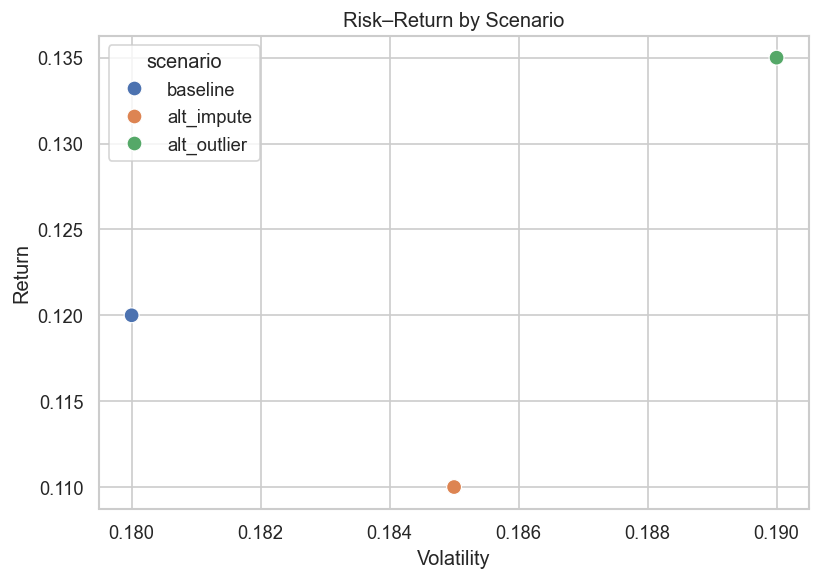

In [6]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='volatility', y='return', hue='scenario', s=80)
plt.title('Risk–Return by Scenario')
plt.xlabel('Volatility')
plt.ylabel('Return')
savefig('risk_return.png')
plt.show()

### Chart 1 — Risk–Return by Scenario

**What the plot shows:**  
The chart compares expected return and volatility across the three scenarios.

**Key stakeholder insight:**  
The baseline scenario provides a 12% return at 18% volatility. The alternative outlier scenario generates the highest return at 13.5%, but volatility also rises to 19%. The alternative imputation scenario has the lowest return at 11%.

**Assumption / limitation:**  
Higher expected return should not automatically be interpreted as a better outcome because the scenarios also differ in risk and depend on different data-handling assumptions.

## Chart 2: Return by Scenario (Bar Chart)

Saved return_by_scenario.png


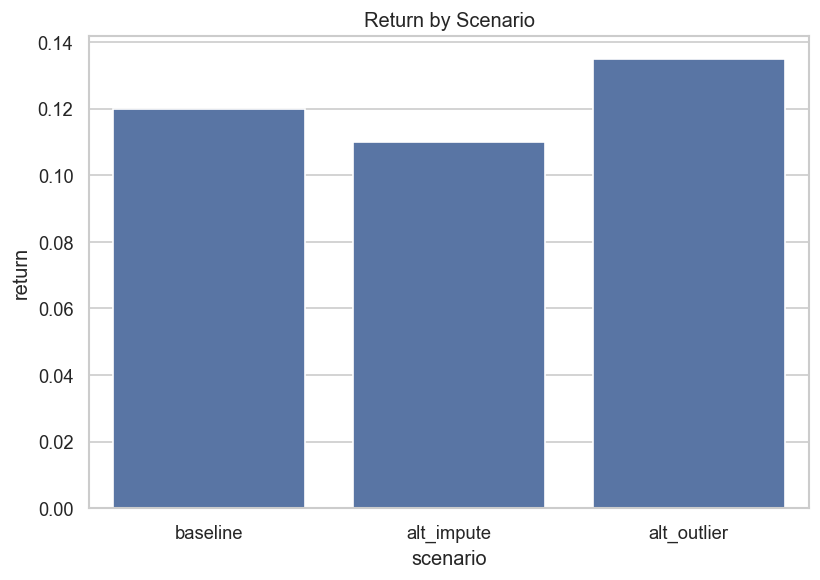

In [7]:
plt.figure(figsize=(7,5))
sns.barplot(data=df, x='scenario', y='return')
plt.title('Return by Scenario')
savefig('return_by_scenario.png')
plt.show()

### Chart 2 — Return by Scenario

**What the plot shows:**  
The bar chart compares expected returns across the baseline and alternative scenarios.

**Key stakeholder insight:**  
The alternative outlier scenario produces the highest return at 13.5%, compared with 12% for the baseline. The alternative imputation scenario reduces expected return to 11%.

**Assumption / limitation:**  
The differences are based on scenario assumptions rather than guaranteed future outcomes. The higher-return scenario should also be evaluated together with its volatility and the plausibility of its underlying assumptions.

## Chart 3: MetricA Over Time (Line Chart)

Saved metricA_over_time.png


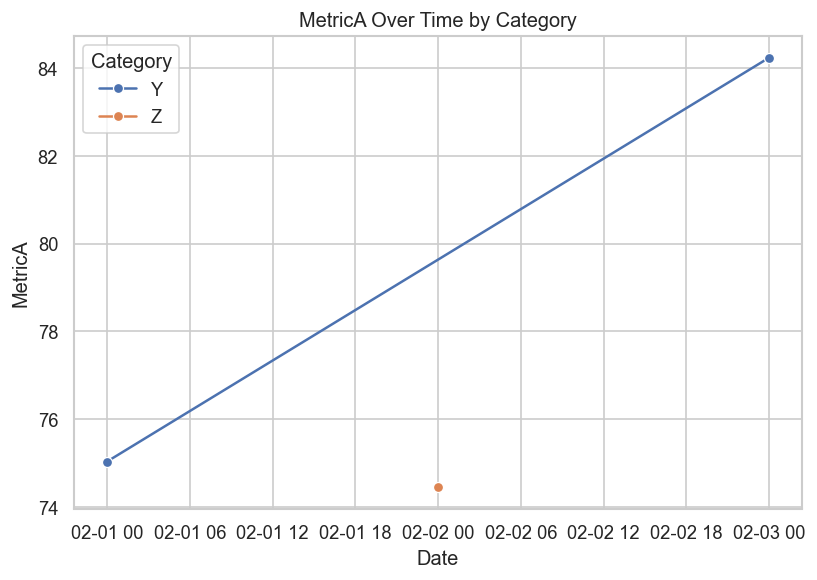

In [8]:
plt.figure(figsize=(7,5))
sns.lineplot(data=df, x='Date', y='MetricA', hue='Category', marker='o')
plt.title('MetricA Over Time by Category')
plt.xlabel('Date')
plt.ylabel('MetricA')
savefig('metricA_over_time.png')
plt.show()

### Chart 3 — MetricA Over Time

**What the plot shows:**  
The chart illustrates how MetricA varies across the available dates and categories.

**Key stakeholder insight:**  
MetricA changes across observations, highlighting that results may not remain constant across time or categories.

**Assumption / limitation:**  
The synthetic fallback contains only a small number of observations, so this chart should be treated as an illustration of reporting design rather than strong evidence of a stable time-series trend.

## Sensitivity Analysis / Assumptions Table

In [9]:
assumptions = pd.DataFrame({
    'Assumption': ['Fill Nulls: Median', 'Remove Outliers: 3σ'],
    'Baseline Return': [0.12, 0.12],
    'Alt Scenario Return': [0.10, 0.14]
})
assumptions

,Assumption,Baseline Return,Alt Scenario Return
0,Fill Nulls: Median,0.12,0.10
1,Remove Outliers: 3σ,0.12,0.14


In [10]:
assumptions["Delta"] = (
    assumptions["Alt Scenario Return"]
    - assumptions["Baseline Return"]
)

assumptions

,Assumption,Baseline Return,Alt Scenario Return,Delta
0,Fill Nulls: Median,0.12,0.10,-0.02
1,Remove Outliers: 3σ,0.12,0.14,0.02


In [11]:
assumptions[
    "Percent Change"
] = (
    assumptions["Delta"]
    / assumptions["Baseline Return"]
    * 100
)

assumptions

,Assumption,Baseline Return,Alt Scenario Return,Delta,Percent Change
0,Fill Nulls: Median,0.12,0.10,-0.02,-16.666667
1,Remove Outliers: 3σ,0.12,0.14,0.02,16.666667


### Chart 4 — Sensitivity to Alternative Assumptions


Saved sensitivity_analysis.png


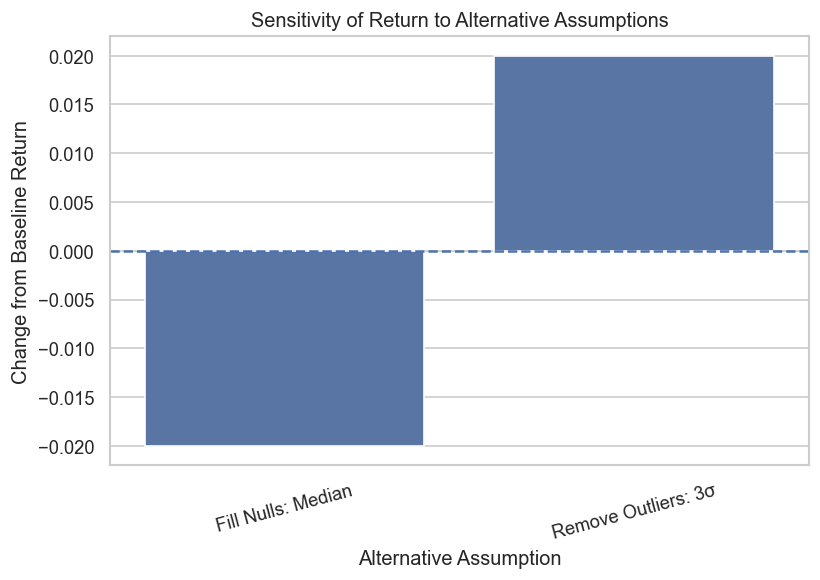

In [12]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=assumptions,
    x="Assumption",
    y="Delta"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Sensitivity of Return to Alternative Assumptions"
)

plt.xlabel(
    "Alternative Assumption"
)

plt.ylabel(
    "Change from Baseline Return"
)

plt.xticks(
    rotation=15
)

savefig(
    "sensitivity_analysis.png"
)

plt.show()

### Chart 4 — Sensitivity to Alternative Assumptions

**What the plot shows:**  
The chart shows how expected return changes relative to the 12% baseline under two alternative assumptions.

**Key stakeholder insight:**  
Changing the missing-value treatment reduces return from 12% to 10%, while the alternative outlier treatment increases return from 12% to 14%. This means that reasonable changes in data-processing assumptions can shift expected return by about 2 percentage points in either direction.

**Assumption / limitation:**  
These scenario results are sensitivity tests rather than forecasts. They show how strongly the reported return depends on modeling and data-processing choices.

## Interpretations / Takeaways

- **Chart 1 takeaway:**  
  The baseline scenario provides a moderate risk-return profile with a 12% return and 18% volatility. The alternative outlier scenario offers the highest return at 13.5%, but also has the highest volatility at 19%. Therefore, the highest-return scenario is not automatically the best choice because it also involves greater risk.

- **Chart 2 takeaway:**  
  Expected return varies across the three scenarios. The alternative imputation scenario lowers return to 11%, while the alternative outlier scenario raises it to 13.5%. This shows that reported performance is sensitive to the assumptions used in data preparation.

- **Chart 3 takeaway:**  
  MetricA varies across the available dates and categories, suggesting that results may differ across observations rather than remain constant. However, the synthetic dataset contains only three observations, so this chart should be interpreted as an illustration rather than evidence of a reliable long-term trend.

- **Chart 4 takeaway:**  
  The sensitivity analysis shows that changing key assumptions can move expected return from the 12% baseline to approximately 10% or 14%. This ±2 percentage-point change is large enough to affect stakeholder decisions, so the baseline result should be treated as a central estimate rather than a precise forecast.

- **Assumptions and sensitivity note:**  
  The analysis depends on choices about missing-value treatment and outlier handling. Because these assumptions materially affect the results, stakeholders should evaluate the baseline together with the alternative scenarios instead of relying on a single estimate.

## Decision Implications

- **Use the baseline as a reference, not a guaranteed outcome.**  
  The 12% baseline return provides a useful central estimate, but sensitivity analysis suggests that reasonable assumption changes can move expected return between approximately 10% and 14%.

- **Consider risk together with return.**  
  The alternative outlier scenario produces the highest return, but it also has the highest volatility. A higher expected return therefore comes with additional risk and should not be selected based on return alone.

- **Treat data-processing assumptions as a decision risk.**  
  Changes in missing-value treatment and outlier handling materially affect reported performance. These assumptions should be reviewed before using the results for important decisions.

- **Opportunity:**  
  The alternative outlier scenario may offer improved return if the underlying assumption is appropriate and the additional volatility is acceptable to stakeholders.

- **Key risk:**  
  The current analysis uses a very small synthetic dataset, so the results should not be interpreted as strong evidence of future performance.

- **Recommended next step:**  
  Validate the analysis using a larger real-world dataset, test additional sensitivity scenarios, and confirm that the chosen missing-data and outlier assumptions remain appropriate before making a high-impact decision.

### Save Notebook
Remember to save as `homework12_results-reporting-delivery-design_submission.ipynb`.